<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"


### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [4]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
import pandas as pd

file_path = "dataset.csv"
df = pd.read_csv(file_path, header=0)

<ipython-input-4-92db74e11101>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [6]:
# Generate description for all dtypes, including object types
description = df.describe(include='all')
# Print to stdout
print(description)

        Unnamed: 0 Manufacturer    Category   Screen         GPU          OS  \
count   238.000000          238  238.000000      238  238.000000  238.000000   
unique         NaN           11         NaN        2         NaN         NaN   
top            NaN         Dell         NaN  Full HD         NaN         NaN   
freq           NaN           71         NaN      161         NaN         NaN   
mean    118.500000          NaN    3.205882      NaN    2.151261    1.058824   
std      68.848868          NaN    0.776533      NaN    0.638282    0.235790   
min       0.000000          NaN    1.000000      NaN    1.000000    1.000000   
25%      59.250000          NaN    3.000000      NaN    2.000000    1.000000   
50%     118.500000          NaN    3.000000      NaN    2.000000    1.000000   
75%     177.750000          NaN    4.000000      NaN    3.000000    1.000000   
max     237.000000          NaN    5.000000      NaN    3.000000    2.000000   

          CPU_core  Screen_Size_cm  CPU

In [9]:
missing_counts = df.isnull().sum()
print(type(missing_counts))
columns_with_missing = missing_counts[missing_counts > 0].index.tolist()
print("Columns with missing values:", columns_with_missing)
print("Missing value counts per column:")
print(missing_counts)

<class 'pandas.core.series.Series'>
Columns with missing values: ['Screen_Size_cm', 'Weight_kg']
Missing value counts per column:
Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
dtype: int64


In [10]:
# 1) Screen_Size_cm: fill missing with the most frequent value
modes = df['Screen_Size_cm'].mode()
if not modes.empty:
    df['Screen_Size_cm'] = df['Screen_Size_cm'].fillna(modes.iloc[0])

# 2) Weight_kg: fill missing with the mean
df['Weight_kg'] = df['Weight_kg'].fillna(df['Weight_kg'].mean())

In [11]:
# Convert to float dtype for the specified columns
df['Screen_Size_cm'] = df['Screen_Size_cm'].astype(float)
df['Weight_kg'] = df['Weight_kg'].astype(float)

In [12]:
# Convert and rename
df['Screen_Size_inch'] = df['Screen_Size_cm'] / 2.54
df['Weight_pounds'] = df['Weight_kg'] * 2.20462262185

# Remove old columns
df = df.drop(columns=['Screen_Size_cm', 'Weight_kg'])

In [13]:
max_val = df['CPU_frequency'].max()
if pd.notna(max_val) and max_val != 0:
    df['CPU_frequency'] = df['CPU_frequency'] / max_val
else:
    print("Normalization skipped: max value is NaN or zero.")

In [14]:
# 1) Create indicator variables for the 'Screen' column
df1 = pd.get_dummies(df['Screen'], prefix='Screen')

# 2) Append the indicator variables to the original dataframe
df = pd.concat([df, df1], axis=1)

# 3) Drop the original 'Screen' column
df = df.drop(columns=['Screen'])

In [15]:
df.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,CPU_frequency,RAM_GB,Storage_GB_SSD,Price,Screen_Size_inch,Weight_pounds,Screen_Full HD,Screen_IPS Panel
0,0,Acer,4,2,1,5,0.551724,8,256,978,14.0,3.527396,False,True
1,1,Dell,3,1,1,3,0.689655,4,256,634,15.6,4.850170,True,False
2,2,Dell,3,1,1,7,0.931034,8,256,946,15.6,4.850170,True,False
3,3,Dell,4,2,1,5,0.551724,8,128,1244,13.3,2.689640,False,True
4,4,HP,4,2,1,7,0.620690,8,256,837,15.6,4.210829,True,False


In [16]:
# Define the current USD to EUR exchange rate
usd_to_eur = 0.92  # replace with the actual rate

# Convert the 'Price' column from USD to EUR in place
#df['Price'] = df['Price'].astype(float) * usd_to_eur

# If you prefer to keep the original USD values, create a new column instead:
df['Price_EUR'] = df['Price'].astype(float) * usd_to_eur


In [17]:
# Ensure the column is numeric
df['CPU_frequency'] = pd.to_numeric(df['CPU_frequency'], errors='coerce')

min_val = df['CPU_frequency'].min()
max_val = df['CPU_frequency'].max()
range_val = max_val - min_val

if pd.notna(min_val) and pd.notna(max_val) and range_val != 0:
    df['CPU_frequency'] = (df['CPU_frequency'] - min_val) / range_val
else:
    print("Min-max normalization skipped: invalid min/max or zero range.")

In [19]:
df.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,CPU_frequency,RAM_GB,Storage_GB_SSD,Price,Screen_Size_inch,Weight_pounds,Screen_Full HD,Screen_IPS Panel,Price_EUR
0,0,Acer,4,2,1,5,0.235294,8,256,978,14.0,3.527396,False,True,899.76
1,1,Dell,3,1,1,3,0.470588,4,256,634,15.6,4.850170,True,False,583.28
2,2,Dell,3,1,1,7,0.882353,8,256,946,15.6,4.850170,True,False,870.32
3,3,Dell,4,2,1,5,0.235294,8,128,1244,13.3,2.689640,False,True,1144.48
4,4,HP,4,2,1,7,0.352941,8,256,837,15.6,4.210829,True,False,770.04


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1) Regression plots: Price vs numeric features
reg_features = ["CPU_frequency", "Screen_Size_inch", "Weight_pounds"]
for feat in reg_features:
    if feat not in df.columns:
        print(f"Warning: column '{feat}' not found in data. Skipping regression plot for this feature.")
        continue
    if not pd.api.types.is_numeric_dtype(df[feat]):
        print(f"Warning: column '{feat}' is not numeric. Skipping regression plot for this feature.")
        continue
    plt.figure(figsize=(6, 4))
    sns.regplot(x=feat, y="Price", data=df, line_kws={'color': 'red'},
                    scatter_kws={'alpha': 0.6})
    plt.xlabel(feat)
    plt.ylabel("Price")
    plt.title(f"{feat} vs Price (regression)")
    plt.tight_layout()
    plt.savefig(f"regplot_{feat}_vs_Price.png")
    plt.close()

In [19]:
# 2) Box plots: Price by categories/bin for each feature
box_features = ["Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"]
for feat in box_features:
    if feat not in df.columns:
        print(f"Warning: column '{feat}' not found in data. Skipping box plot for this feature.")
        continue

    temp = df.copy()

    # If numeric, bin into a few categories for a reasonable box plot
    if pd.api.types.is_numeric_dtype(temp[feat]):
        n_unique = temp[feat].nunique(dropna=True)
        if n_unique > 20:
            bin_col = f"{feat}_binned"
            temp[bin_col] = pd.cut(temp[feat], bins=6, include_lowest=True).astype(str)
            xcol = bin_col
        else:
            xcol = f"{feat}_as_category"
            temp[xcol] = temp[feat].astype(str)
    else:
        xcol = feat
        temp[xcol] = temp[feat].astype(str)

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=xcol, y="Price", data=temp)
    plt.xlabel(feat)
    plt.ylabel("Price")
    plt.title(f"Price by {feat}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"boxplot_{feat}_vs_Price.png")
    plt.close()

In [28]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

target = 'Price'
# get all numeric columns, exclude the target
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c != target and c != 'Unnamed: 0' and c != 'Price_EUR']
print(numeric_cols)

rows = []
for col in numeric_cols:
    data = df[[col, target]].dropna()
    if data.shape[0] < 3:
        # not enough data to compute statistics reliably
        continue

    x = data[col]
    y = data[target]

    # Pearson correlation and p-value
    try:
        pearson_r, pearson_p = pearsonr(x, y)
    except Exception:
        pearson_r, pearson_p = np.nan, np.nan

    # Spearman correlation (rho) and p-value
    try:
        spearman_rho, spearman_p = spearmanr(x, y)
    except Exception:
        spearman_rho, spearman_p = np.nan, np.nan

    rows.append({
            'Attribute': col,
            'Spearman_rho': spearman_rho,
            'Spearman_p': spearman_p,
            'Pearson_r': pearson_r,
            'Pearson_p': pearson_p
    })
# DataFrame with one row per attribute
result = pd.DataFrame(rows).set_index('Attribute')
print(result)

['Category', 'GPU', 'OS', 'CPU_core', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Screen_Size_inch', 'Weight_pounds']
                  Spearman_rho    Spearman_p  Pearson_r     Pearson_p
Attribute                                                            
Category              0.384251  8.578496e-10   0.286243  7.225696e-06
GPU                   0.231573  3.147719e-04   0.288298  6.166950e-06
OS                   -0.254850  6.984778e-05  -0.221730  5.696643e-04
CPU_core              0.442976  7.364602e-13   0.459398  7.912950e-14
CPU_frequency         0.402743  1.075195e-10   0.366666  5.502463e-09
RAM_GB                0.575599  2.125838e-22   0.549297  3.681561e-20
Storage_GB_SSD        0.279913  1.167869e-05   0.243421  1.489892e-04
Screen_Size_inch     -0.265403  3.361150e-05  -0.110644  8.853398e-02
Weight_pounds        -0.318398  5.239423e-07  -0.050312  4.397694e-01


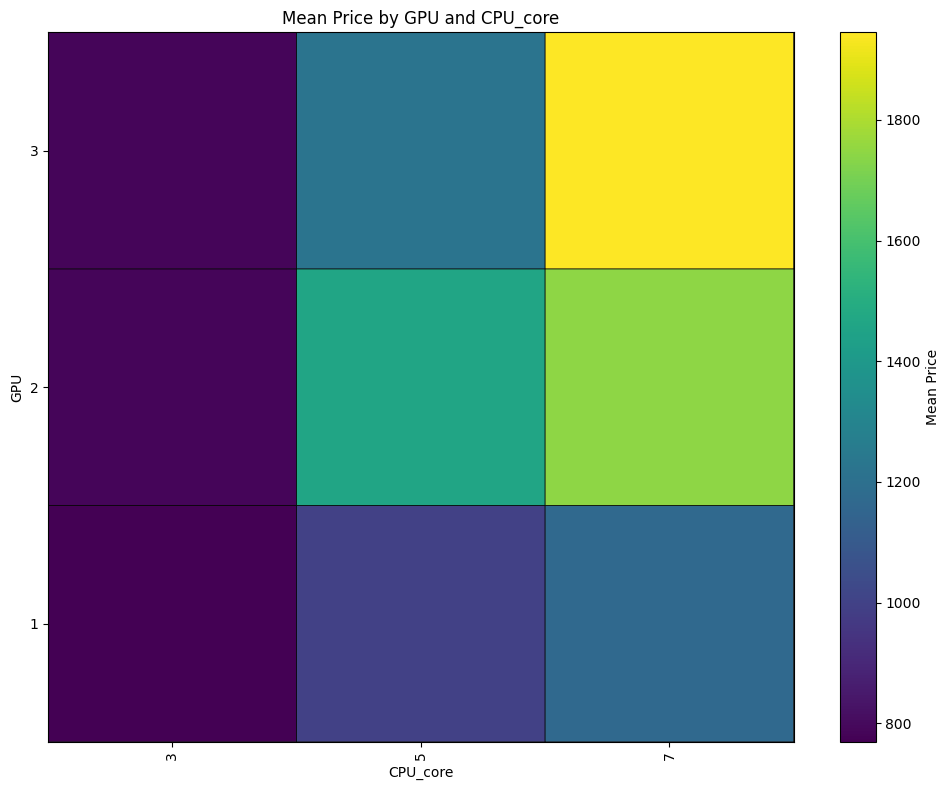

In [29]:
gpu_col='GPU'
cpu_col='CPU_core'
target='Price'
# Check availability of required columns
if gpu_col not in df.columns or cpu_col not in df.columns or target not in df.columns:
    missing = [c for c in [gpu_col, cpu_col, target] if c not in df.columns]
    raise ValueError(f"Missing required column(s) in dataframe: {', '.join(missing)}")

# Create pivot table: rows -> GPU, columns -> CPU_core, values -> mean Price
pivot = df.pivot_table(index=gpu_col, columns=cpu_col, values=target, aggfunc='mean')

if pivot.empty:
    raise ValueError("Pivot table is empty. Check the data and column values.")

# Plot using pcolor
plt.figure(figsize=(10, 8))
# Mask NaNs so they are not plotted as zeros
masked = np.ma.masked_invalid(pivot.values)
# pcolor with shading for proper alignment (requires matplotlib >= 3.3 for 'shading')
cm = plt.cm.viridis
p = plt.pcolor(masked, cmap=cm, edgecolors='k', linewidths=0.5, shading='auto')
plt.colorbar(p, label=f'Mean {target}')

# Set axis labels and ticks
plt.xlabel(cpu_col)
plt.ylabel(gpu_col)
plt.title(f'Mean {target} by {gpu_col} and {cpu_col}')

plt.xticks(np.arange(0.5, pivot.shape[1], 1), [str(c) for c in pivot.columns], rotation=90)
plt.yticks(np.arange(0.5, pivot.shape[0], 1), [str(r) for r in pivot.index])

plt.tight_layout()
plt.show()

## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
